In [23]:
import pandas as pd
import numpy as np
from fredapi import Fred
from dotenv import load_dotenv
import os
import time

# Load environment variables
load_dotenv()
api_key = os.getenv("fred_api_key")
if not api_key:
    raise ValueError("FRED_API_KEY not found in .env file")

fred = Fred(api_key=api_key)
start_date = '2015-01-01'

# The file where we will permanently store the raw data
RAW_DATA_FILE = 'raw_state_data.csv'

# Robust fetcher to handle FRED's "Internal Server Errors" automatically
def fetch_with_retry(ticker, retries=3, delay=1):
    for attempt in range(retries):
        try:
            time.sleep(0.6)  # Built-in pause to respect FRED's rate limit
            return fred.get_series(ticker, observation_start=start_date)
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(delay * (attempt + 1)) # Wait longer on each failure
            else:
                print(f"    [!] Permanently failed to fetch {ticker}: {e}")
                return None
                
print("FRED API & Smart Fetcher Initialized.")

FRED API & Smart Fetcher Initialized.


In [27]:
import os
import requests

bls_api_key = os.getenv("bls_api_key")
if not bls_api_key:
    raise ValueError("bls_api_key not found in .env — check sigey2@illinois.edu for the BLS email")

print("Fetching state-level data for the Top 25 US States...")

states = {
    'CA': '06', 'TX': '48', 'NY': '36', 'FL': '12', 'IL': '17',
    'PA': '42', 'OH': '39', 'GA': '13', 'NJ': '34', 'NC': '37',
    'WA': '53', 'MA': '25', 'VA': '51', 'MI': '26', 'CO': '08',
    'TN': '47', 'MD': '24', 'AZ': '04', 'IN': '18', 'MN': '27',
    'WI': '55', 'MO': '29', 'CT': '09', 'SC': '45', 'NV': '32'
}

RAW_DATA_FILE = 'raw_state_data.csv'

BLS_API_URL = "https://api.bls.gov/publicAPI/v2/timeseries/data/"

def fetch_bls_jolts(state_fips, start_year='2015', end_year='2023'):
    """
    Fetch state-level JOLTS openings and hires from the BLS API v2.
    Series ID format (21 chars):
      JT + S(adj) + 000000(total nonfarm) + {2-digit FIPS} + 00000(area) + 00(size) + {element} + L(level)
    """
    o_id = f'JTS000000{state_fips}0000000JOL'  # Job Openings, level, seasonally adjusted
    h_id = f'JTS000000{state_fips}0000000HIL'  # Hires, level, seasonally adjusted

    payload = {
        "seriesid": [o_id, h_id],
        "startyear": start_year,
        "endyear": end_year,
        "registrationkey": bls_api_key   # BLS v2 key goes here, inside the JSON body
    }

    response = requests.post(BLS_API_URL, json=payload)
    response.raise_for_status()
    data = response.json()

    if data["status"] != "REQUEST_SUCCEEDED":
        return None, None

    results = {}
    for series in data["Results"]["series"]:
        rows = []
        for obs in series["data"]:
            if obs["value"] == "-":
                continue
            date = pd.Timestamp(f"{obs['year']}-{obs['period'][1:]}-01")
            rows.append((date, float(obs["value"])))
        if rows:
            results[series["seriesID"]] = pd.Series(dict(rows)).sort_index()

    openings = results.get(o_id)
    hires    = results.get(h_id)
    return openings, hires


if os.path.exists(RAW_DATA_FILE):
    print(f"Found local cache! Loading {RAW_DATA_FILE} instantly without hitting the API.")
    df_raw = pd.read_csv(RAW_DATA_FILE)
else:
    print("Commencing download (this will take a few minutes)...")
    panel_data = []

    for state_abbr, fips in states.items():
        print(f"  -> Processing: {state_abbr}", end="  ", flush=True)
        try:
            # JOLTS: openings & hires come from BLS API (not on FRED)
            openings, hires = fetch_bls_jolts(fips)

            if openings is None or hires is None:
                print("[SKIPPED — JOLTS unavailable for this state]")
                continue

            # Everything else still comes from FRED
            labor_force  = fetch_with_retry(f'{state_abbr}LF')
            unemployment = fetch_with_retry(f'{state_abbr}UR')
            wage         = fetch_with_retry(f'SMU{fips}000000500000003')
            lh_emp       = fetch_with_retry(f'SMU{fips}000000700000001')

            data_dict = {
                'Openings':          openings,
                'Hires':             hires,
                'Labor_Force':       labor_force,
                'Unemployment_Rate': unemployment,
                'Hourly_Wage':       wage,
                'LH_Employment':     lh_emp,
            }

            temp_df = pd.DataFrame(data_dict)
            temp_df['State'] = state_abbr
            temp_df = temp_df[temp_df.index >= start_date]
            panel_data.append(temp_df)
            print(f"[OK — {temp_df.dropna().shape[0]} clean months]")

        except Exception as e:
            print(f"\n      [!] Unexpected error for {state_abbr}: {e}")

    df_raw = pd.concat(panel_data)
    df_raw.index.name = 'Date'
    df_raw = df_raw.reset_index()

    print("\nMissing values per column before drop:")
    print(df_raw.isna().sum().to_string())
    n_before = len(df_raw)
    df_raw = df_raw.dropna()
    print(f"Rows dropped: {n_before - len(df_raw):,}  |  Rows retained: {len(df_raw):,}")

    df_raw.to_csv(RAW_DATA_FILE, index=False)
    print(f"\nSuccess! Raw data saved to {RAW_DATA_FILE}")


print("\nEngineering Final Panel Features...")
df_final = df_raw.copy()

df_final['ln_Wage']        = np.log(df_final['Hourly_Wage'])
df_final['Hiring_Rate']    = (df_final['Hires'] * 1000) / df_final['Labor_Force']
df_final['Friction_Proxy'] = ((df_final['Openings'] - df_final['Hires']) * 1000) / df_final['Labor_Force']
df_final['LH_Share']       = df_final['LH_Employment'] / df_final['Labor_Force']

final_csv = 'state_labor_panel_data.csv'
df_final.to_csv(final_csv, index=False)
print(f"Feature engineering complete. Final analytical dataset saved to: {final_csv}")

display(df_final.tail())

Fetching state-level data for the Top 25 US States...
Commencing download (this will take a few minutes)...
  -> Processing: CA  [OK — 108 clean months]
  -> Processing: TX  [OK — 108 clean months]
  -> Processing: NY  [OK — 108 clean months]
  -> Processing: FL  [OK — 108 clean months]
  -> Processing: IL  [OK — 108 clean months]
  -> Processing: PA  [OK — 108 clean months]
  -> Processing: OH  [OK — 108 clean months]
  -> Processing: GA  [OK — 108 clean months]
  -> Processing: NJ  [OK — 108 clean months]
  -> Processing: NC  [OK — 108 clean months]
  -> Processing: WA  [OK — 108 clean months]
  -> Processing: MA  [OK — 108 clean months]
  -> Processing: VA  [OK — 108 clean months]
  -> Processing: MI  [OK — 108 clean months]
  -> Processing: CO  [OK — 108 clean months]
  -> Processing: TN  [OK — 108 clean months]
  -> Processing: MD  [OK — 108 clean months]
  -> Processing: AZ  [OK — 108 clean months]
  -> Processing: IN  [OK — 108 clean months]
  -> Processing: MN  [OK — 108 clean 

,Date,Openings,Hires,Labor_Force,Unemployment_Rate,Hourly_Wage,LH_Employment,State,ln_Wage,Hiring_Rate,Friction_Proxy,LH_Share
3319,2023-08-01,100.0,60.0,1613655.0,5.1,29.40,1337.3,NV,3.380995,0.037183,0.024788,0.000829
3320,2023-09-01,98.0,57.0,1616788.0,5.1,29.43,1361.0,NV,3.382015,0.035255,0.025359,0.000842
3321,2023-10-01,82.0,63.0,1619393.0,5.2,29.33,1373.3,NV,3.378611,0.038903,0.011733,0.000848
3322,2023-11-01,90.0,59.0,1621615.0,5.2,28.82,1382.6,NV,3.361070,0.036383,0.019117,0.000853
3323,2023-12-01,78.0,62.0,1623639.0,5.2,29.31,1384.3,NV,3.377929,0.038186,0.009854,0.000853


## Dataset Description — State Labor Market Panel

Each row is one **state-month** observation from January 2015 to December 2023.

| Column | Source | Description |
|---|---|---|
| `Date` | — | First day of the observation month |
| `State` | — | 2-letter state abbreviation |
| `Openings` | BLS JOLTS | Number of job openings that month, in **thousands** |
| `Hires` | BLS JOLTS | Number of hires completed that month, in **thousands** |
| `Labor_Force` | BLS LAUS | Civilian labor force (employed + actively job-seeking), in **thousands** |
| `Unemployment_Rate` | BLS LAUS | Share of the labor force that is unemployed, in **percent** |
| `Hourly_Wage` | BLS CES | Average hourly earnings for all private-sector workers, in **dollars** |
| `LH_Employment` | BLS CES | Number of workers employed in Leisure & Hospitality, in **thousands** |
| `ln_Wage` | Engineered | Natural log of `Hourly_Wage` — our **outcome variable** |
| `Hiring_Rate` | Engineered | `(Hires × 1000) / Labor_Force` — effective labor demand scaled to state size |
| `Friction_Proxy` | Engineered | `((Openings − Hires) × 1000) / Labor_Force` — our **key predictor**; positive values mean more openings went unfilled |
| `LH_Share` | Engineered | `LH_Employment / Labor_Force` — leisure & hospitality concentration, used as a control for states with service-heavy economies |

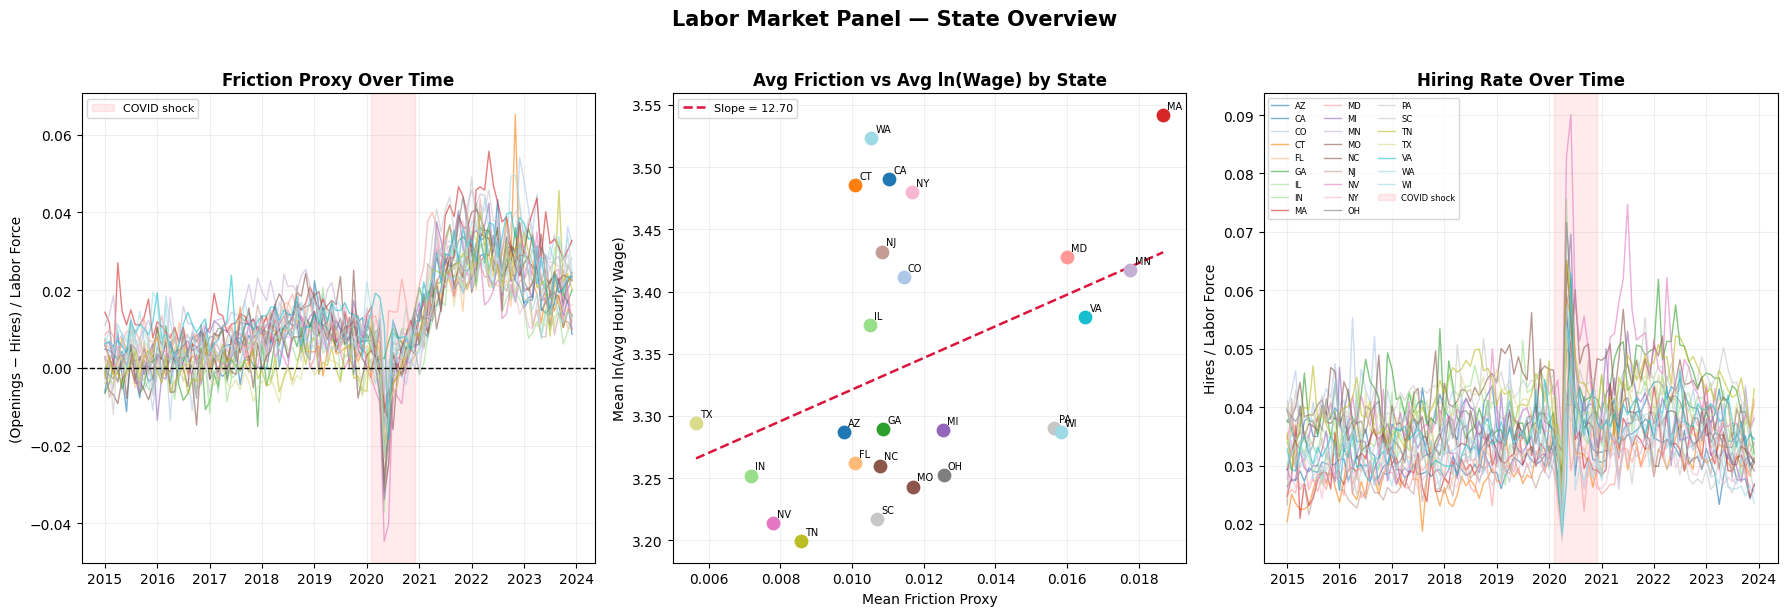

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df = pd.read_csv('state_labor_panel_data.csv', parse_dates=['Date'])

STATES     = sorted(df['State'].unique())
COLORS     = cm.tab20(np.linspace(0, 1, len(STATES)))
STATE_COLOR = dict(zip(STATES, COLORS))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Labor Market Panel — State Overview', fontsize=15, fontweight='bold', y=1.02)

# ── 1. Friction Proxy over time, one line per state ───────────────────────────
ax = axes[0]
for st in STATES:
    sub = df[df['State'] == st].sort_values('Date')
    ax.plot(sub['Date'], sub['Friction_Proxy'],
            color=STATE_COLOR[st], linewidth=1, alpha=0.6)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-12-01'),
           alpha=0.08, color='red', label='COVID shock')
ax.set_title('Friction Proxy Over Time', fontweight='bold')
ax.set_ylabel('(Openings − Hires) / Labor Force')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# ── 2. State averages: Friction vs Wage (labeled scatter) ────────────────────
ax = axes[1]
state_avg = df.groupby('State')[['Friction_Proxy', 'ln_Wage']].mean()
for st, row in state_avg.iterrows():
    ax.scatter(row['Friction_Proxy'], row['ln_Wage'],
               color=STATE_COLOR[st], s=80, zorder=3)
    ax.annotate(st, (row['Friction_Proxy'], row['ln_Wage']),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')
m, b = np.polyfit(state_avg['Friction_Proxy'], state_avg['ln_Wage'], 1)
x_line = np.linspace(state_avg['Friction_Proxy'].min(),
                     state_avg['Friction_Proxy'].max(), 100)
ax.plot(x_line, m * x_line + b, color='crimson',
        linewidth=1.8, linestyle='--', label=f'Slope = {m:.2f}')
ax.set_title('Avg Friction vs Avg ln(Wage) by State', fontweight='bold')
ax.set_xlabel('Mean Friction Proxy')
ax.set_ylabel('Mean ln(Avg Hourly Wage)')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# ── 3. Hiring Rate over time, one line per state ──────────────────────────────
ax = axes[2]
for st in STATES:
    sub = df[df['State'] == st].sort_values('Date')
    ax.plot(sub['Date'], sub['Hiring_Rate'],
            color=STATE_COLOR[st], linewidth=1, alpha=0.6, label=st)
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-12-01'),
           alpha=0.08, color='red', label='COVID shock')
ax.set_title('Hiring Rate Over Time', fontweight='bold')
ax.set_ylabel('Hires / Labor Force')
ax.legend(ncol=3, fontsize=6, loc='upper left')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('eda_simplified.png', dpi=150, bbox_inches='tight')
plt.show()